In [1]:
import pandas as pd
import numpy as np

#%pip install matplotlib
#%pip install yfinance
%pip install hmmlearn
from scipy import stats

import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

Note: you may need to restart the kernel to use updated packages.


In [2]:
df_cesi = pd.read_csv('data/processed/cesi_limpo.csv', index_col =0, parse_dates = True)

In [3]:
#teste
dados_spy = yf.download("SPY", start="2004-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
print(dados_spy.head())

Price           Close       High        Low       Open    Volume
Ticker            SPY        SPY        SPY        SPY       SPY
Date                                                            
2004-01-02  73.644157  74.279762  73.313113  73.981819  38072300
2004-01-05  74.445320  74.498283  73.882540  73.948753  27959800
2004-01-06  74.518127  74.637304  74.153976  74.259913  20472800
2004-01-07  74.769722  74.855792  74.081149  74.412193  30170400
2004-01-08  75.067673  75.087540  74.663798  74.981603  36438400


In [5]:
dados_spy


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2004-01-02,73.644157,74.279762,73.313113,73.981819,38072300
2004-01-05,74.445320,74.498283,73.882540,73.948753,27959800
2004-01-06,74.518127,74.637304,74.153976,74.259913,20472800
2004-01-07,74.769722,74.855792,74.081149,74.412193,30170400
2004-01-08,75.067673,75.087540,74.663798,74.981603,36438400
...,...,...,...,...,...
2026-08-04,771.330017,773.409973,760.520020,760.630005,69154800
2026-08-05,769.789978,776.849976,769.510010,775.849976,44689100


In [6]:
dados_spy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5686 entries, 2004-01-02 to 2026-08-10
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   5686 non-null   float64
 1   (High, SPY)    5686 non-null   float64
 2   (Low, SPY)     5686 non-null   float64
 3   (Open, SPY)    5686 non-null   float64
 4   (Volume, SPY)  5686 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 266.5 KB


In [7]:
preco_spy = dados_spy['Close']

retornos_spy = np.log(preco_spy/preco_spy.shift(1))

retornos_spy.head()

Ticker,SPY
Date,
2004-01-02,NaN
2004-01-05,0.010820
2004-01-06,0.000978
2004-01-07,0.003371
2004-01-08,0.003977


In [8]:
df_modelo = pd.concat([retornos_spy, df_cesi['cesi_global']], axis=1).dropna()
df_modelo.columns = ['Retorno_SPY', 'CESI_Global']

df_modelo.head()

,Retorno_SPY,CESI_Global
Date,,
2004-01-05,0.010820,40.5
2004-01-06,0.000978,38.5
2004-01-07,0.003371,38.1
2004-01-08,0.003977,35.1
2004-01-09,-0.008770,32.2


In [9]:
dados_modelo = pd.concat([retornos_spy, df_cesi], axis=1).dropna()

print(dados_modelo.head())

                 SPY  cesi_global  cesi_g10  cesi_united_states  \
Date                                                              
2004-01-05  0.010820         40.5      55.5                71.6   
2004-01-06  0.000978         38.5      52.7                65.0   
2004-01-07  0.003371         38.1      50.7                62.3   
2004-01-08  0.003977         35.1      50.1                61.4   
2004-01-09 -0.008770         32.2      45.0                47.7   

            cesi_eurozone  cesi_asia_pacific  cesi_latin_america  \
Date                                                               
2004-01-05           53.6               36.3               -36.1   
2004-01-06           54.7               34.8               -35.1   
2004-01-07           52.1               37.7               -34.0   
2004-01-08           51.7               36.9               -39.9   
2004-01-09           52.6               36.3               -35.8   

            cesi_emerging_markets  cesi_bric  
Date  

In [10]:
window = 20

df_feat = dados_modelo.copy()

df_feat.columns

Index(['SPY', 'cesi_global', 'cesi_g10', 'cesi_united_states', 'cesi_eurozone',
       'cesi_asia_pacific', 'cesi_latin_america', 'cesi_emerging_markets',
       'cesi_bric'],
      dtype='object')

In [11]:
df_feat = df_feat.rename(columns={'SPY': 'retorno'})

In [12]:
df_feat['volatilidade'] = df_feat['retorno'].rolling(window).std()
df_feat['retorno_acumulado'] = df_feat['retorno'].rolling(window).sum()
df_feat['abs_retorno_acumulado'] = df_feat['retorno_acumulado'].abs()

def autocorr_lag1(x):
    return pd.Series(x).autocorr(lag=1)

In [13]:
# Efficiency Ratio: substitui abs_retorno_acumulado como medida de "direcionalidade"
df_feat['soma_abs_retornos'] = df_feat['retorno'].abs().rolling(window).sum()
df_feat['efficiency_ratio'] = df_feat['abs_retorno_acumulado'] / df_feat['soma_abs_retornos']
df_feat['efficiency_ratio'].describe()

count    5.650000e+03
mean     2.420065e-01
std      1.687020e-01
min      1.690812e-16
25%      1.078184e-01
50%      2.162022e-01
75%      3.460405e-01
max      8.696817e-01
Name: efficiency_ratio, dtype: float64

In [14]:
df_feat['autocorr'] = df_feat['retorno'].rolling(window).apply(autocorr_lag1, raw=False)

df_feat = df_feat.dropna()
df_feat[['retorno', 'volatilidade', 'retorno_acumulado', 'autocorr']].describe()

,retorno,volatilidade,retorno_acumulado,autocorr
count,5650.000000,5650.000000,5650.000000,5650.000000
mean,0.000406,0.009712,0.008118,-0.082394
std,0.011779,0.006804,0.045297,0.202503
min,-0.115886,0.002007,-0.370871,-0.718571
25%,-0.003938,0.005877,-0.011274,-0.223724
50%,0.000726,0.007975,0.014712,-0.081893
75%,0.005756,0.011311,0.033289,0.060713
max,0.135578,0.059197,0.212052,0.741797


In [15]:

def trend_r2(price_window):
    y = price_window.values
    x = np.arange(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return r_value ** 2  # 0 a 1: quão bem o preço se ajusta a uma reta

def trend_slope_sign(price_window):
    y = price_window.values
    x = np.arange(len(y))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return slope  # sinal indica direção, magnitude indica inclinação

df_feat['log_price'] = np.log(preco_spy.reindex(df_feat.index))
df_feat['trend_r2'] = df_feat['log_price'].rolling(window).apply(trend_r2, raw=False)
df_feat['trend_slope'] = df_feat['log_price'].rolling(window).apply(trend_slope_sign, raw=False)

df_feat[['trend_r2', 'trend_slope']].describe()

,trend_r2,trend_slope
count,5.631000e+03,5631.000000
mean,4.658644e-01,0.000405
std,2.951801e-01,0.002481
min,4.745588e-07,-0.017933
25%,1.931016e-01,-0.000663
50%,4.877933e-01,0.000793
75%,7.343994e-01,0.001790
max,9.782689e-01,0.010855


In [16]:
df_feat = df_feat.dropna(subset=['trend_r2', 'trend_slope'])

features_stage1 = ['volatilidade', 'trend_r2', 'autocorr']
X1 = df_feat[features_stage1].values

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

modelo_stage1 = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)
modelo_stage1.fit(X1_scaled)

df_feat['estado_stage1'] = modelo_stage1.predict(X1_scaled)

resumo_stage1 = df_feat.groupby('estado_stage1')[features_stage1].mean()
print(resumo_stage1)

estado_direcional = resumo_stage1['trend_r2'].idxmax()
estado_lateral = resumo_stage1['trend_r2'].idxmin()

df_feat['regime_principal'] = df_feat['estado_stage1'].map({
    estado_lateral: 'Lateral',
    estado_direcional: 'Direcional'
})
df_feat['regime_principal'].value_counts()

               volatilidade  trend_r2  autocorr
estado_stage1                                  
0                  0.006671  0.482939 -0.075495
1                  0.016453  0.428217 -0.097189


regime_principal
Direcional    3874
Lateral       1757
Name: count, dtype: int64

In [17]:
#sub-nó: dentro de "Direcional", separa Alta vs Baixa pelo sinal
mask_direcional = df_feat['regime_principal'] == 'Direcional'

df_feat['regime_final'] = df_feat['regime_principal']
df_feat.loc[mask_direcional, 'regime_final'] = np.where(
    df_feat.loc[mask_direcional, 'trend_slope'] > 0,
    'Direcional - Alta',
    'Direcional - Baixa'
)

df_feat['regime_final'].value_counts()

regime_final
Direcional - Alta     2879
Lateral               1757
Direcional - Baixa     995
Name: count, dtype: int64

In [18]:
transmat = pd.DataFrame(
    modelo_stage1.transmat_,
    index=['De_Estado_0', 'De_Estado_1'],
    columns=['Para_Estado_0', 'Para_Estado_1']
)
print(transmat)

# media esperada em cada estado (em dias de pregão)
# Fórmula: 1 / (1 - probabilidade de permanecer no mesmo estado)
for i in range(2):
    prob_permanecer = modelo_stage1.transmat_[i, i]
    duracao_esperada = 1 / (1 - prob_permanecer)
    nome = 'Lateral' if i == estado_lateral else 'Direcional'
    print(f"Estado {i} ({nome}): prob. de permanecer = {prob_permanecer:.3f} | duração média esperada = {duracao_esperada:.1f} dias")

             Para_Estado_0  Para_Estado_1
De_Estado_0       0.992661       0.007339
De_Estado_1       0.016066       0.983934
Estado 0 (Direcional): prob. de permanecer = 0.993 | duração média esperada = 136.3 dias
Estado 1 (Lateral): prob. de permanecer = 0.984 | duração média esperada = 62.2 dias


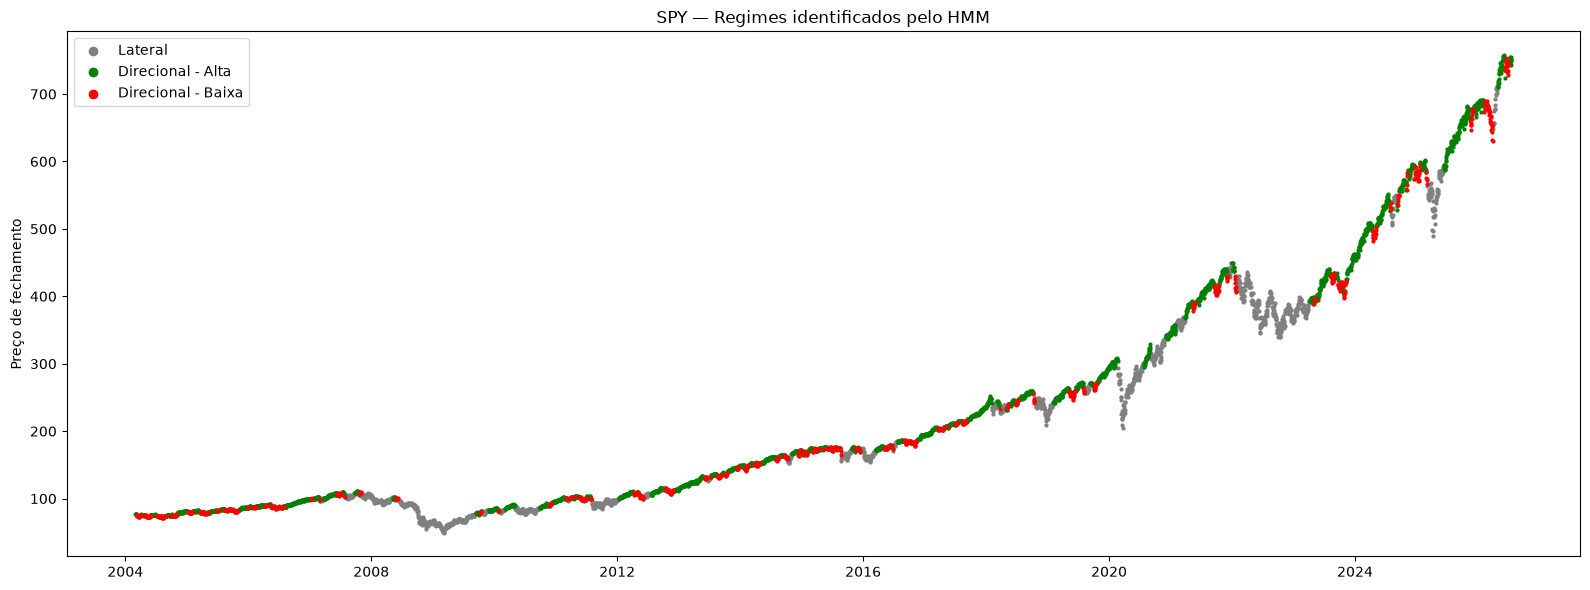

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))

cores = {'Lateral': 'gray', 'Direcional - Alta': 'green', 'Direcional - Baixa': 'red'}

preco_plot = preco_spy.reindex(df_feat.index)

for regime, cor in cores.items():
    mask = df_feat['regime_final'] == regime
    ax.scatter(df_feat.index[mask], preco_plot[mask], c=cor, s=4, label=regime)

ax.set_title('SPY — Regimes identificados pelo HMM')
ax.set_ylabel('Preço de fechamento')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [20]:
features_stage1 = ['volatilidade', 'trend_r2', 'autocorr']
X1 = df_feat[features_stage1].values

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

modelo_stage1 = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)
modelo_stage1.fit(X1_scaled)

df_feat['estado_stage1'] = modelo_stage1.predict(X1_scaled)

resumo_stage1 = df_feat.groupby('estado_stage1')[features_stage1].mean()
print(resumo_stage1)

estado_direcional = resumo_stage1['trend_r2'].idxmax()
estado_lateral = resumo_stage1['trend_r2'].idxmin()

df_feat['regime_principal'] = df_feat['estado_stage1'].map({
    estado_lateral: 'Lateral',
    estado_direcional: 'Direcional'
})
df_feat['regime_principal'].value_counts()

               volatilidade  trend_r2  autocorr
estado_stage1                                  
0                  0.006671  0.482939 -0.075495
1                  0.016453  0.428217 -0.097189


regime_principal
Direcional    3874
Lateral       1757
Name: count, dtype: int64